In [5]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
import os
from google.colab import files

In [6]:
# =========================
# 1. ЗАГРУЗКА JSONL ФАЙЛА
# =========================
print("📤 Загрузите файл annotations.jsonl ...")
uploaded = files.upload()

# Находим имя загруженного файла
jsonl_filename = list(uploaded.keys())[0]
print(f"Файл загружен: {jsonl_filename}")

📤 Загрузите файл annotations.jsonl ...


Saving annotations.jsonl to annotations (1).jsonl
Файл загружен: annotations (1).jsonl


In [10]:
# =========================
# 2. ПАРСИНГ JSONL И ФОРМИРОВАНИЕ ДАТАФРЕЙМА
# =========================
print("\n📂 Парсинг JSONL файла...")

data = []
model_names = ["Gemma", "Qwen", "Yandex VML"]

with open(jsonl_filename, 'r', encoding='utf-8') as f:
    for line_num, line in enumerate(f, 1):
        line = line.strip()
        if not line:
            continue
        try:
            record = json.loads(line)

            # Определяем source (человек/модель) аналогично старому коду
            raw_source = record.get("raw_source", "")
            text_column = record.get("source", "")

            if raw_source.startswith("человек") or raw_source.startswith("человек_"):
                source = "человек"
            elif any(model in raw_source for model in model_names):
                source = "модель"
            else:
                # дополнительная проверка по text_column
                if text_column.startswith("Описание_"):
                    source = "человек"
                elif any(model in text_column for model in model_names):
                    source = "модель"
                else:
                    source = "неопределено"

            # Извлекаем поля с дефолтными значениями, если отсутствуют
            row = {
                "image_id": record.get("id", ""),
                "text_column": text_column,
                "source": source,
                "keyword": record.get("keyword", ""),
                "context": record.get("context", ""),
                "sentiment": record.get("sentiment", "neutral"),
                "emotion": record.get("emotion", "none"),
                "cognitive_type": record.get("cognitive_type", "unknown"),
                "subtype": record.get("subtype", "unknown"),
                "concreteness": record.get("concreteness", "unknown"),
                "modality": record.get("modality", "unknown")
            }
            data.append(row)

        except Exception as e:
            print(f"⚠️ Ошибка в строке {line_num}: {e}")

df = pd.DataFrame(data)
print(f"\n✅ Загружено {len(df)} аннотаций")
print(f"Уникальных изображений: {df['image_id'].nunique()}")
print(f"Источники: {df['source'].unique().tolist()}")


📂 Парсинг JSONL файла...

✅ Загружено 19371 аннотаций
Уникальных изображений: 895
Источники: ['человек', 'модель']


In [8]:
# =========================
# 3. СОХРАНЕНИЕ ДАТАФРЕЙМА
# =========================
df.to_csv("annotations_df.csv", index=False)
print("\n💾 Датафрейм сохранен как annotations_df.csv")
print(df.head(10))


💾 Датафрейм сохранен как annotations_df.csv
  image_id text_column   source   keyword                      context  \
0   id_699  Описание_1  человек   портрет              портрет мужчины   
1   id_742  Описание_1  человек    черную              в черную одежду   
2   id_832  Описание_1  человек   эполеты    на плечах золотые эполеты   
3   id_698  Описание_2  человек   молодой            молодой мужчина в   
4   id_854  Описание_2  человек     синий                 синий цветов   
5   id_239        Qwen     Qwen    момент           момент сострадания   
6   id_674  Описание_3  человек   женщина           на лестнице одного   
7   id_535       Gemma    Gemma     стены  акцент на разрушенные стены   
8   id_754  Описание_3  человек   мужчина             ещё один мужчина   
9   id_709  Описание_3  человек  золотыми          золотыми пуговицами   

  cognitive_type          subtype  
0     perceptual             item  
1     perceptual            color  
2     perceptual    clothing ite

In [11]:
# =========================
# 4. БАЗОВАЯ СТАТИСТИКА
# =========================
print("\n" + "="*60)
print("📊 БАЗОВАЯ СТАТИСТИКА")
print("="*60)

# Статистика по источникам
source_stats = df.groupby('source').agg({
    'keyword': 'count',
    'image_id': 'nunique'
}).rename(columns={'keyword': 'total_keywords', 'image_id': 'unique_images'})
print("\nСтатистика по источникам:")
print(source_stats)

# Распределение cognitive_type
print("\nРаспределение cognitive_type:")
cognitive_dist = pd.crosstab(df['source'], df['cognitive_type'], normalize='index') * 100
print(cognitive_dist.round(1))


📊 БАЗОВАЯ СТАТИСТИКА

Статистика по источникам:
         total_keywords  unique_images
source                                
модель            10566            895
человек            8805            895

Распределение cognitive_type:
cognitive_type  interpretive  none  perceptual  unknown
source                                                 
модель                  37.2   0.0        62.8      0.0
человек                 10.0   0.0        89.9      0.1


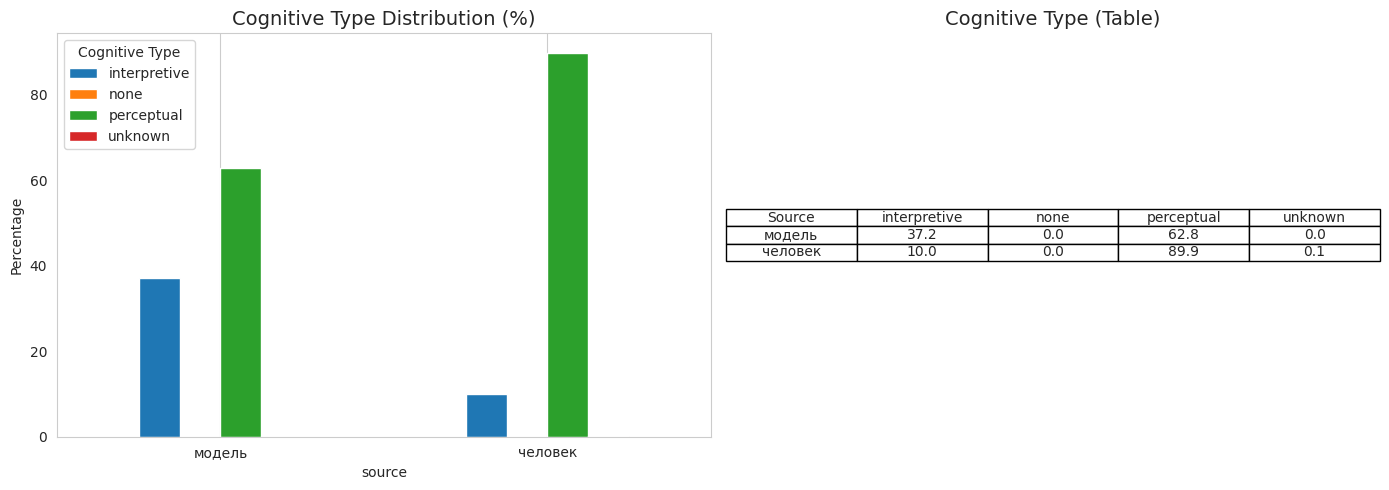

In [12]:
# =========================
# 5. ВИЗУАЛИЗАЦИИ
# =========================
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# 5.1 Cognitive Type распределение
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cognitive_counts = df.groupby(['source', 'cognitive_type']).size().unstack(fill_value=0)
cognitive_counts_pct = cognitive_counts.div(cognitive_counts.sum(axis=1), axis=0) * 100

cognitive_counts_pct.plot(kind='bar', ax=axes[0], rot=0)
axes[0].set_title('Cognitive Type Distribution (%)', fontsize=14)
axes[0].set_ylabel('Percentage')
axes[0].legend(title='Cognitive Type')
axes[0].grid(axis='y')

axes[1].axis('tight')
axes[1].axis('off')
table_data = cognitive_counts_pct.round(1).reset_index().values.tolist()
table_cols = ['Source'] + list(cognitive_counts_pct.columns)
table = axes[1].table(cellText=table_data, colLabels=table_cols,
                      cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
axes[1].set_title('Cognitive Type (Table)', fontsize=14)

plt.tight_layout()
plt.savefig('cognitive_type_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


🏷️ SUBTYPE АНАЛИЗ

🔍 ТОП-10 SUBTYPES (PERCEPTUAL) - ЧЕЛОВЕК:
subtype
color                   1564
item                     971
object property          948
person property          885
nature and landscape     765
person type              714
clothing item            583
action                   503
spatial                  441
architecture             242

🤖 ТОП-10 SUBTYPES (PERCEPTUAL) - МОДЕЛЬ:
subtype
color                   1375
item                     940
object property          777
nature and landscape     736
person type              536
person property          464
action                   462
clothing item            426
spatial                  377
architecture             250

🔍 ТОП-10 SUBTYPES (INTERPRETIVE) - ЧЕЛОВЕК:
subtype
clothing property       172
religion                131
artistic property       129
activity                 84
social role              73
status marker            65
none                     62
emotion                  45
mood                   

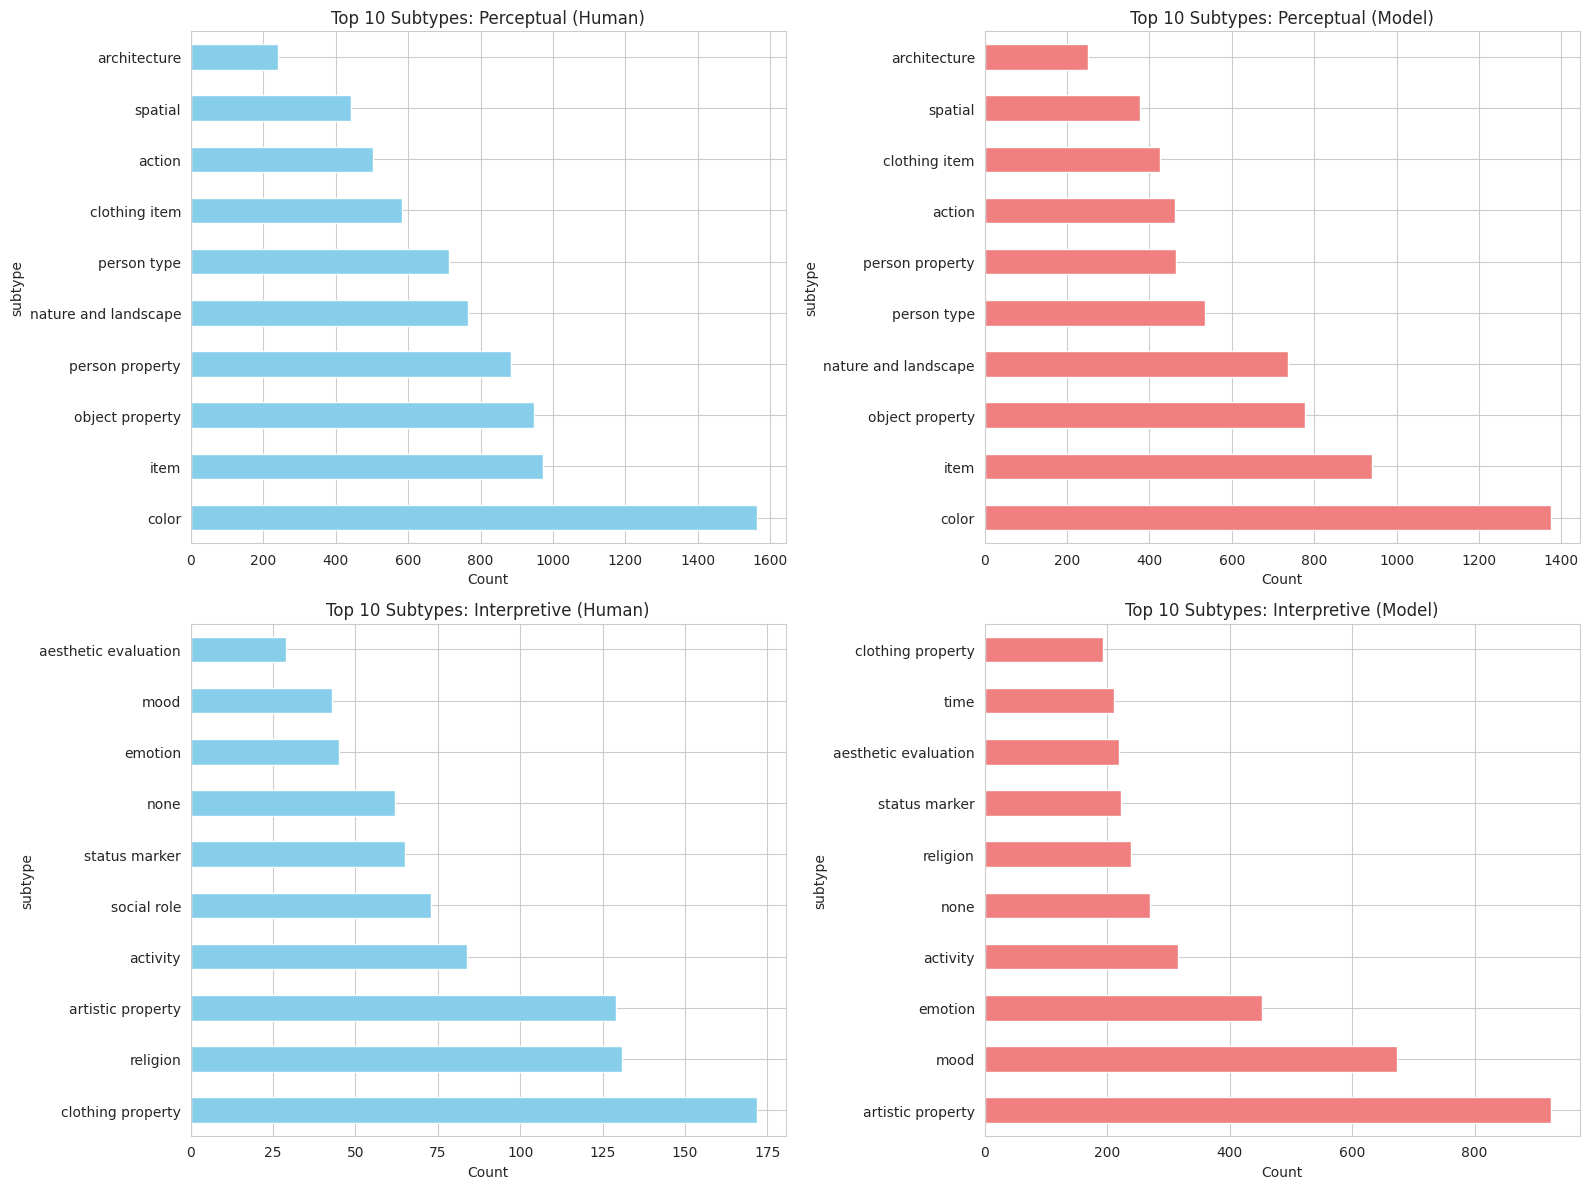

In [13]:
# =========================
# 6. SUBTYPE АНАЛИЗ
# =========================
print("\n" + "="*60)
print("🏷️ SUBTYPE АНАЛИЗ")
print("="*60)

PERCEPTUAL_SUBTYPES = [
    "person type", "person property", "clothing item", "color",
    "nature and landscape", "architecture", "spatial", "animal",
    "action", "item", "object property", "none"
]

INTERPRETIVE_SUBTYPES = [
    "emotion", "mood", "social role", "time", "religion",
    "artistic property", "color", "activity", "clothing property",
    "aesthetic evaluation", "status marker", "none"
]

# Для perceptual
df_perceptual = df[df['cognitive_type'] == 'perceptual']
if not df_perceptual.empty:
    perceptual_human = df_perceptual[df_perceptual['source'] == 'человек']['subtype'].value_counts().head(10)
    perceptual_model = df_perceptual[df_perceptual['source'] == 'модель']['subtype'].value_counts().head(10)

    print("\n🔍 ТОП-10 SUBTYPES (PERCEPTUAL) - ЧЕЛОВЕК:")
    print(perceptual_human.to_string())
    print("\n🤖 ТОП-10 SUBTYPES (PERCEPTUAL) - МОДЕЛЬ:")
    print(perceptual_model.to_string())
else:
    print("\nНет данных для cognitive_type='perceptual'")

# Для interpretive
df_interpretive = df[df['cognitive_type'] == 'interpretive']
if not df_interpretive.empty:
    interpretive_human = df_interpretive[df_interpretive['source'] == 'человек']['subtype'].value_counts().head(10)
    interpretive_model = df_interpretive[df_interpretive['source'] == 'модель']['subtype'].value_counts().head(10)

    print("\n🔍 ТОП-10 SUBTYPES (INTERPRETIVE) - ЧЕЛОВЕК:")
    print(interpretive_human.to_string())
    print("\n🤖 ТОП-10 SUBTYPES (INTERPRETIVE) - МОДЕЛЬ:")
    print(interpretive_model.to_string())
else:
    print("\nНет данных для cognitive_type='interpretive'")

# Визуализация subtypes
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Perceptual - Human
if not df_perceptual.empty and not perceptual_human.empty:
    perceptual_human.plot(kind='barh', ax=axes[0,0], color='skyblue')
    axes[0,0].set_title('Top 10 Subtypes: Perceptual (Human)', fontsize=12)
else:
    axes[0,0].text(0.5, 0.5, 'No data', ha='center', va='center')
    axes[0,0].set_title('Top 10 Subtypes: Perceptual (Human)', fontsize=12)
axes[0,0].set_xlabel('Count')

# Perceptual - Model
if not df_perceptual.empty and not perceptual_model.empty:
    perceptual_model.plot(kind='barh', ax=axes[0,1], color='lightcoral')
    axes[0,1].set_title('Top 10 Subtypes: Perceptual (Model)', fontsize=12)
else:
    axes[0,1].text(0.5, 0.5, 'No data', ha='center', va='center')
    axes[0,1].set_title('Top 10 Subtypes: Perceptual (Model)', fontsize=12)
axes[0,1].set_xlabel('Count')

# Interpretive - Human
if not df_interpretive.empty and not interpretive_human.empty:
    interpretive_human.plot(kind='barh', ax=axes[1,0], color='skyblue')
    axes[1,0].set_title('Top 10 Subtypes: Interpretive (Human)', fontsize=12)
else:
    axes[1,0].text(0.5, 0.5, 'No data', ha='center', va='center')
    axes[1,0].set_title('Top 10 Subtypes: Interpretive (Human)', fontsize=12)
axes[1,0].set_xlabel('Count')

# Interpretive - Model
if not df_interpretive.empty and not interpretive_model.empty:
    interpretive_model.plot(kind='barh', ax=axes[1,1], color='lightcoral')
    axes[1,1].set_title('Top 10 Subtypes: Interpretive (Model)', fontsize=12)
else:
    axes[1,1].text(0.5, 0.5, 'No data', ha='center', va='center')
    axes[1,1].set_title('Top 10 Subtypes: Interpretive (Model)', fontsize=12)
axes[1,1].set_xlabel('Count')

plt.tight_layout()
plt.savefig('subtypes_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

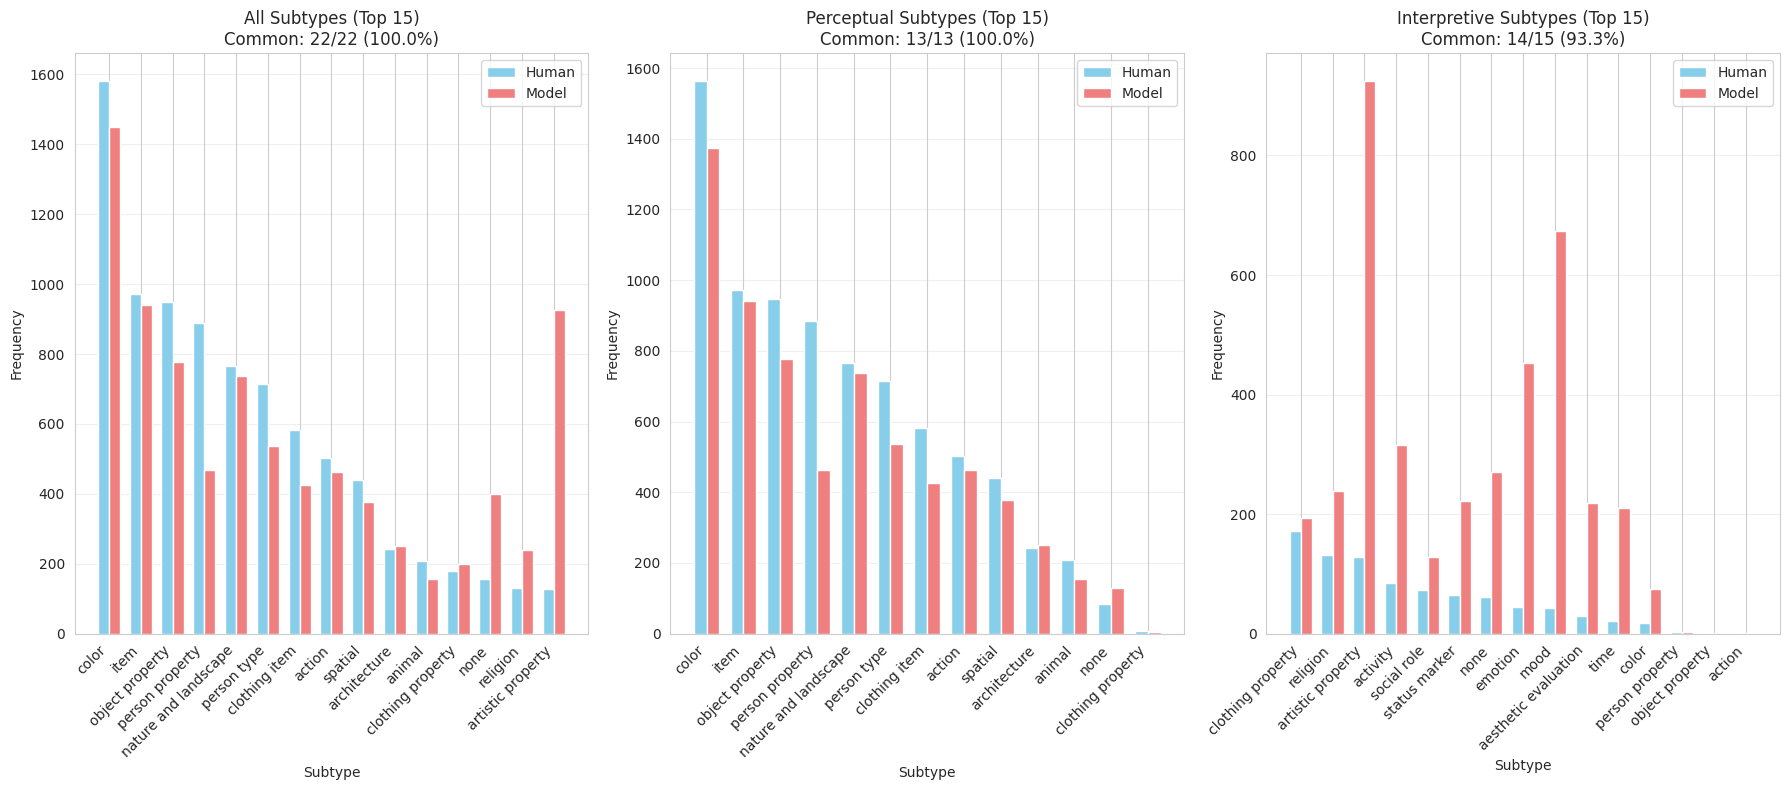

In [14]:
# =========================
# 7. ВИЗУАЛИЗАЦИЯ СРАВНЕНИЯ SUBTYPES
# =========================
# Подготовка данных для сравнения: человеческие vs модельные типы для всех, perceptual, interpretive
def get_subtype_comparison(df_subset, title_prefix):
    """Возвращает DataFrame с частотами subtype для человека и модели"""
    human_counts = df_subset[df_subset['source'] == 'человек']['subtype'].value_counts()
    model_counts = df_subset[df_subset['source'] == 'модель']['subtype'].value_counts()
    all_subtypes = sorted(set(human_counts.index) | set(model_counts.index))
    comp_df = pd.DataFrame({
        'subtype': all_subtypes,
        'human_count': [human_counts.get(st, 0) for st in all_subtypes],
        'model_count': [model_counts.get(st, 0) for st in all_subtypes]
    })
    comp_df = comp_df.sort_values('human_count', ascending=False)
    return comp_df

all_df = get_subtype_comparison(df, 'All')
common_all = set(all_df[all_df['human_count'] > 0]['subtype']) & set(all_df[all_df['model_count'] > 0]['subtype'])
only_human_all = set(all_df[(all_df['human_count'] > 0) & (all_df['model_count'] == 0)]['subtype'])
only_model_all = set(all_df[(all_df['human_count'] == 0) & (all_df['model_count'] > 0)]['subtype'])

# Perceptual
if not df_perceptual.empty:
    perc_df = get_subtype_comparison(df_perceptual, 'Perceptual')
    common_perc = set(perc_df[perc_df['human_count'] > 0]['subtype']) & set(perc_df[perc_df['model_count'] > 0]['subtype'])
    only_human_perc = set(perc_df[(perc_df['human_count'] > 0) & (perc_df['model_count'] == 0)]['subtype'])
    only_model_perc = set(perc_df[(perc_df['human_count'] == 0) & (perc_df['model_count'] > 0)]['subtype'])
else:
    perc_df = pd.DataFrame()
    common_perc = set(); only_human_perc = set(); only_model_perc = set()

# Interpretive
if not df_interpretive.empty:
    interp_df = get_subtype_comparison(df_interpretive, 'Interpretive')
    common_interp = set(interp_df[interp_df['human_count'] > 0]['subtype']) & set(interp_df[interp_df['model_count'] > 0]['subtype'])
    only_human_interp = set(interp_df[(interp_df['human_count'] > 0) & (interp_df['model_count'] == 0)]['subtype'])
    only_model_interp = set(interp_df[(interp_df['human_count'] == 0) & (interp_df['model_count'] > 0)]['subtype'])
else:
    interp_df = pd.DataFrame()
    common_interp = set(); only_human_interp = set(); only_model_interp = set()

fig, axes = plt.subplots(1, 3, figsize=(18, 8))

# All Subtypes
top_all = all_df.head(15)
x = range(len(top_all))
width = 0.35
axes[0].bar([i - width/2 for i in x], top_all['human_count'], width, label='Human', color='skyblue')
axes[0].bar([i + width/2 for i in x], top_all['model_count'], width, label='Model', color='lightcoral')
axes[0].set_xlabel('Subtype')
axes[0].set_ylabel('Frequency')
axes[0].set_title(f'All Subtypes (Top 15)\nCommon: {len(common_all)}/{len(all_df)} ({len(common_all)/len(all_df)*100:.1f}%)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(top_all['subtype'], rotation=45, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Perceptual
if not perc_df.empty:
    top_perc = perc_df.head(15)
    axes[1].bar([i - width/2 for i in x[:len(top_perc)]], top_perc['human_count'], width, label='Human', color='skyblue')
    axes[1].bar([i + width/2 for i in x[:len(top_perc)]], top_perc['model_count'], width, label='Model', color='lightcoral')
    axes[1].set_xlabel('Subtype')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title(f'Perceptual Subtypes (Top 15)\nCommon: {len(common_perc)}/{len(perc_df)} ({len(common_perc)/len(perc_df)*100:.1f}%)')
    axes[1].set_xticks(x[:len(top_perc)])
    axes[1].set_xticklabels(top_perc['subtype'], rotation=45, ha='right')
    axes[1].legend()
    axes[1].grid(axis='y', alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'No perceptual data', ha='center', va='center')
    axes[1].set_title('Perceptual Subtypes', fontsize=12)

# Interpretive
if not interp_df.empty:
    top_interp = interp_df.head(15)
    axes[2].bar([i - width/2 for i in x[:len(top_interp)]], top_interp['human_count'], width, label='Human', color='skyblue')
    axes[2].bar([i + width/2 for i in x[:len(top_interp)]], top_interp['model_count'], width, label='Model', color='lightcoral')
    axes[2].set_xlabel('Subtype')
    axes[2].set_ylabel('Frequency')
    axes[2].set_title(f'Interpretive Subtypes (Top 15)\nCommon: {len(common_interp)}/{len(interp_df)} ({len(common_interp)/len(interp_df)*100:.1f}%)')
    axes[2].set_xticks(x[:len(top_interp)])
    axes[2].set_xticklabels(top_interp['subtype'], rotation=45, ha='right')
    axes[2].legend()
    axes[2].grid(axis='y', alpha=0.3)
else:
    axes[2].text(0.5, 0.5, 'No interpretive data', ha='center', va='center')
    axes[2].set_title('Interpretive Subtypes', fontsize=12)

plt.tight_layout()
plt.savefig('subtypes_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# =========================
# 8. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ В EXCEL
# =========================
with pd.ExcelWriter('analysis_results.xlsx', engine='openpyxl') as writer:
    source_stats.to_excel(writer, sheet_name='Source_Stats')
    cognitive_counts_pct.to_excel(writer, sheet_name='Cognitive_Type')
    all_df.to_excel(writer, sheet_name='All_Subtypes', index=False)
    if not perc_df.empty:
        perc_df.to_excel(writer, sheet_name='Perceptual_Subtypes', index=False)
    if not interp_df.empty:
        interp_df.to_excel(writer, sheet_name='Interpretive_Subtypes', index=False)

    summary = pd.DataFrame({
        'Category': ['All', 'Perceptual', 'Interpretive'],
        'Total_Subtypes': [len(all_df), len(perc_df) if not perc_df.empty else 0, len(interp_df) if not interp_df.empty else 0],
        'Common': [len(common_all), len(common_perc) if not perc_df.empty else 0, len(common_interp) if not interp_df.empty else 0],
        'Only_Human': [len(only_human_all), len(only_human_perc) if not perc_df.empty else 0, len(only_human_interp) if not interp_df.empty else 0],
        'Only_Model': [len(only_model_all), len(only_model_perc) if not perc_df.empty else 0, len(only_model_interp) if not interp_df.empty else 0],
        'Overlap_%': [
            len(common_all)/len(all_df)*100,
            len(common_perc)/len(perc_df)*100 if not perc_df.empty else 0,
            len(common_interp)/len(interp_df)*100 if not interp_df.empty else 0
        ]
    })
    summary.to_excel(writer, sheet_name='Summary', index=False)

print("\n✅ Результаты сохранены в analysis_results.xlsx")
print(f"   - Всего subtypes: {len(all_df)}")
print(f"   - Совпало: {len(common_all)} ({len(common_all)/len(all_df)*100:.1f}%)")
print(f"   - Только у человека: {len(only_human_all)}")
print(f"   - Только у модели: {len(only_model_all)}")


✅ Результаты сохранены в analysis_results.xlsx
   - Всего subtypes: 22
   - Совпало: 22 (100.0%)
   - Только у человека: 0
   - Только у модели: 0


In [16]:
# =========================
# 9. УПАКОВКА ГРАФИКОВ И СКАЧИВАНИЕ
# =========================
import zipfile

with zipfile.ZipFile('visualizations.zip', 'w') as zipf:
    zipf.write('cognitive_type_analysis.png')
    zipf.write('subtypes_analysis.png')
    zipf.write('subtypes_comparison.png')

print("\n✅ Графики сохранены в visualizations.zip")

# Скачиваем результаты
files.download('annotations_df.csv')
files.download('analysis_results.xlsx')
files.download('visualizations.zip')

print("\n🎉 Анализ завершен! Файлы скачаны.")


✅ Графики сохранены в visualizations.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 Анализ завершен! Файлы скачаны.
